In [1]:
# Deep learning models - MvTec Anamoly detection
# Anamoly detection for category Capsule
# Predict labels -  0 for good images and 1 for defective images
# Binary Classification

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

# Importation pour la transformation sur les images
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomTranslation 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory
#from tensorflow.keras.applications import VGG16
#from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras import layers, models

# Importation pour les visualisations
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics import classification_report_imbalanced

from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter

C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [71]:

df = pd.read_pickle("Data/mvtec_full_images_colour.pkl")
print(df.shape)
#df.head()

df = df[df["category_name"] == 'capsule']
df.head()

(5346, 7)


,file_path,category_name,dir_name,file_name,file_size,label,img
663,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,000.png,1156641,1,"[[[233, 231, 230], [226, 232, 229], [225, 225,..."
664,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,001.png,1175806,1,"[[[223, 222, 223], [228, 227, 228], [222, 220,..."
665,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,002.png,1181720,1,"[[[236, 230, 230], [230, 232, 229], [233, 233,..."
666,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,003.png,1148345,1,"[[[228, 228, 229], [231, 227, 229], [233, 226,..."
667,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,004.png,1151186,1,"[[[231, 226, 232], [237, 236, 227], [236, 232,..."
...,...,...,...,...,...,...,...
1007,..\Projects\mvtec_anomaly_detection\capsule\tr...,capsule,good,213.png,1170233,0,"[[[231, 227, 224], [228, 224, 219], [232, 228,..."
1008,..\Projects\mvtec_anomaly_detection\capsule\tr...,capsule,good,214.png,1165745,0,"[[[230, 226, 227], [228, 224, 223], [228, 226,..."
1009,..\Projects\mvtec_anomaly_detection\capsule\tr...,capsule,good,215.png,1145671,0,"[[[232, 233, 233], [230, 229, 227], [231, 231,..."
1010,..\Projects\mvtec_anomaly_detection\capsule\tr...,capsule,good,216.png,1171192,0,"[[[235, 231, 226], [230, 230, 228], [251, 234,..."


,file_path,category_name,dir_name,file_name,file_size,label,img
663,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,000.png,1156641,1,"[[[233, 231, 230], [226, 232, 229], [225, 225,..."
664,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,001.png,1175806,1,"[[[223, 222, 223], [228, 227, 228], [222, 220,..."
665,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,002.png,1181720,1,"[[[236, 230, 230], [230, 232, 229], [233, 233,..."
666,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,003.png,1148345,1,"[[[228, 228, 229], [231, 227, 229], [233, 226,..."
667,..\Projects\mvtec_anomaly_detection\capsule\te...,capsule,crack,004.png,1151186,1,"[[[231, 226, 232], [237, 236, 227], [236, 232,..."


In [72]:
# Get X and y
# Stack images
X = np.stack(df['img']).astype(np.float32)

# Preprocess for MobileNetV2
#X = preprocess_input(X)
y = df['label'].values
'''
# Encode labels
le = LabelEncoder()
y = le.fit_transform(df_transistor['dir_name'])
class_names = le.classes_
num_classes = len(class_names)
print(class_names)
print(num_classes)
'''
print(Counter(y))


Counter({np.int64(0): 241, np.int64(1): 108})


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [57]:
Counter(y_train)

Counter({np.int64(0): 168, np.int64(1): 76})

In [74]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

X_train = preprocess_input(X_train)
X_val   = preprocess_input(X_val)
X_test  = preprocess_input(X_test)

In [75]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train, y_train, batch_size=8, shuffle=True)
val_gen   = val_datagen.flow(X_val, y_val, batch_size=8, shuffle=False)

In [76]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: class_weights[0], 1: class_weights[1]}
print(class_weights)

{0: np.float64(0.7261904761904762), 1: np.float64(1.605263157894737)}


In [82]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)

base.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(base.input, output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_learning_rate ]
)

model.save('Models/model_predict_label_MobileNet_Capsule_with_Classweights.keras')

C:\Users\kavit\AppData\Local\Temp\ipykernel_12412\1946429023.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 386ms/step - accuracy: 0.5533 - loss: 0.8362 - precision: 0.3398 - recall: 0.4605 - val_accuracy: 0.5192 - val_loss: 0.6826 - val_precision: 0.3448 - val_recall: 0.6250 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 310ms/step - accuracy: 0.5902 - loss: 0.6341 - precision: 0.4032 - recall: 0.6579 - val_accuracy: 0.4231 - val_loss: 0.7215 - val_precision: 0.3333 - val_recall: 0.8750 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 308ms/step - accuracy: 0.6393 - loss: 0.6392 - precision: 0.4455 - recall: 0.6447 - val_accuracy: 0.5385 - val_loss: 0.6877 - val_precision: 0.3824 - val_recall: 0.8125 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.6377 - loss: 0.5787 - precision: 0.4344 - recall: 0.7902
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 293ms/step - accuracy: 0.6885 - loss: 0.5722 - precision: 0.5000 

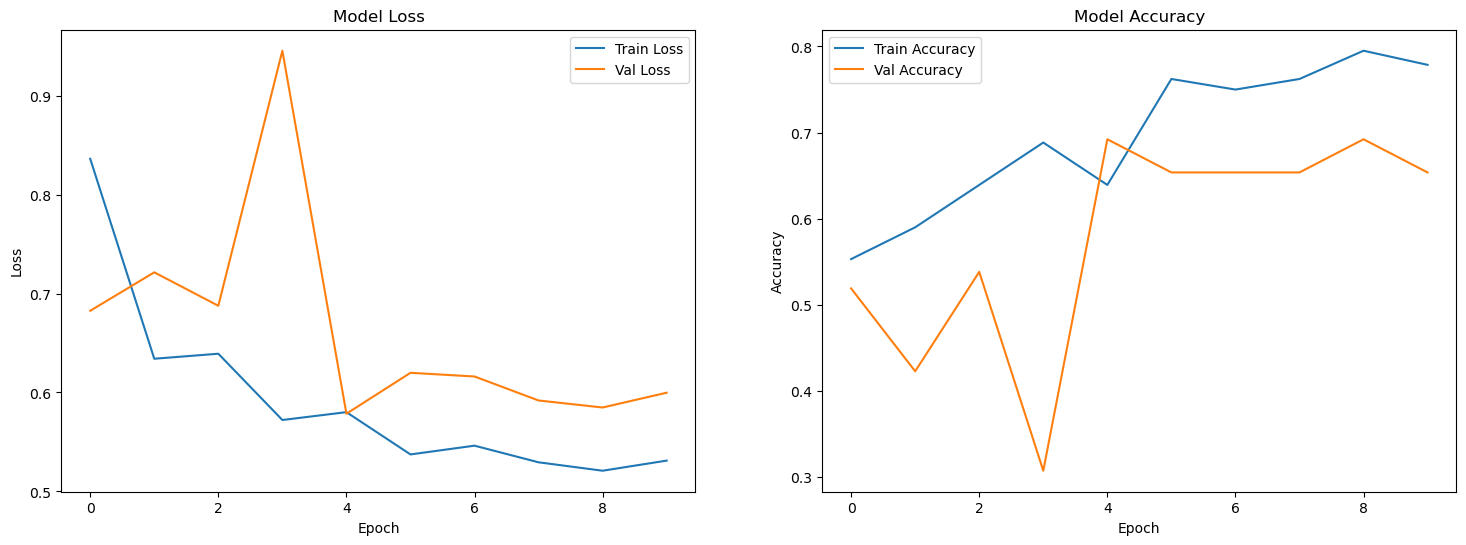

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
              precision    recall  f1-score   support

           0       0.94      0.86      0.90        37
           1       0.74      0.88      0.80        16

    accuracy                           0.87        53
   macro avg       0.84      0.87      0.85        53
weighted avg       0.88      0.87      0.87        53

Validation Accuracy: 0.8679


Text(0.5, 1.0, 'Validation Confusion Matrix')

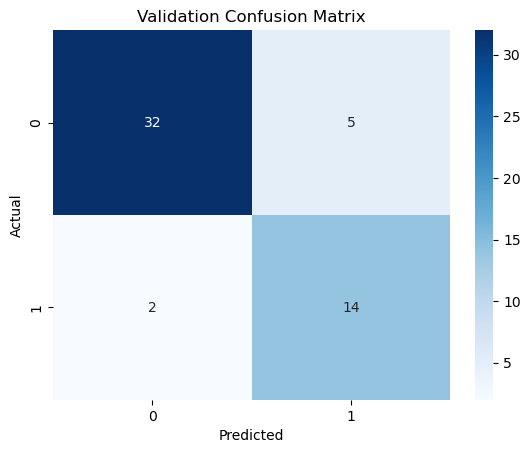

In [83]:
# model_predict_label_MobileNet_Capsule_with_Classweights 
#loaded_model = load_model('Models/model_predict_label_MobileNet_Capsule_with_Classweights.keras')

display_loss_accuracy_graph(history)
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, zero_division=0))

val_acc = accuracy_score(y_test, y_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

val_cm = confusion_matrix(y_test, y_pred)
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

In [86]:
last_conv_layer_name = "Conv_1"
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # defective class (sigmoid)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()
def overlay_gradcam(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = heatmap * alpha + original_img

    return np.uint8(superimposed)


In [88]:
def denormalize_mobilenet_img(img):
    """
    Convert preprocessed MobileNetV2 image [-1,1] -> uint8 [0,255]
    """
    img = (img + 1.0) * 127.5  # [-1,1] -> [0,255]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

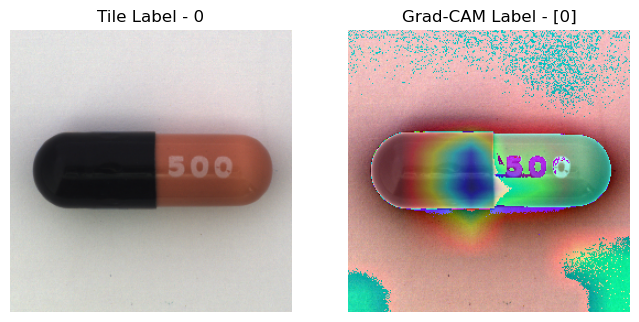

In [98]:
idx = 8  # index from X_test
img = X_test[idx]
#img = preprocess_input(img)
img_input = np.expand_dims(img, axis=0)
heatmap = make_gradcam_heatmap(
    img_input,
    model,
    last_conv_layer_name
)
superimposed_img = overlay_gradcam(
    (img * 255).astype(np.uint8),  # de-normalize if needed
    heatmap
)

original_img = denormalize_mobilenet_img(X_test[idx])


plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.axis("off")
plt.title("Tile Label - "+ str(y_test[idx]))
#plt.title("Tile with oil")

plt.subplot(1,2,2)
plt.imshow(superimposed_img)
plt.axis("off")
plt.title("Grad-CAM Label - "+ str(y_pred[idx]))
#plt.title("Grad-CAM")
plt.show()


In [17]:
def display_loss_accuracy_graph(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]
    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]

    plt.figure(figsize=(18,6))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


In [81]:
early_stopping = EarlyStopping(
                                patience=5, # Attendre 5 epochs avant application
                                min_delta=0.01, # si au bout de 5 epochs la fonction de perte ne varie pas de 1%, 
    # que ce soit à la hausse ou à la baisse, on arrête
                                verbose=1, # Afficher à quel epoch on s'arrête
                                mode='min',
                                monitor='val_loss')

reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # si val_loss stagne sur 3 epochs consécutives selon la valeur min_delta
                                    min_delta=0.01,
                                    factor=0.1,  # On réduit le learning rate d'un facteur 0.1
                                    cooldown=4,  # On attend 4 epochs avant de réitérer 
                                    verbose=1)